# APH/PPH Split — Temporal Ordering & Denominators (MIC-7286)

Blind verification traces for the APH/PPH temporal-ordering iteration. Each section maps to a plan expectation:

1. **APH incidence risk** is a probability in [0, 1] and is applied only to still/live births (0 for `partial_term`).
2. **APH per-birth > per-pregnancy** — dropping the abortion/miscarriage (c995) + ectopic (c374) terms from the denominator raises APH risk (directional artifact trace).
3. **Intrapartum-disorder incidence risks** use denominator `birth_rate - aph_csmr`, so each is slightly larger than `incidence / birth_rate`.
4. **Two-pass mortality / APH-survival gating**: APH deaths and intrapartum-disorder deaths are disjoint; APH-dead simulants carry no intrapartum disorder.
5. **AME** only on `partial_term`; APH/PPH/intrapartum only on still/live births.
6. Only **severe** hemorrhage cases die of hemorrhage.

In [1]:
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import vivarium_gates_mncnh
from vivarium import Artifact, InteractiveContext
from vivarium.framework.configuration import build_model_specification

from vivarium_gates_mncnh.constants.data_keys import (
    MATERNAL_HEMORRHAGE,
    MATERNAL_SEPSIS,
    OBSTRUCTED_LABOR,
    PREGNANCY,
)
from vivarium_gates_mncnh.constants.data_values import (
    COLUMNS,
    HEMORRHAGE_SEVERITY,
    PIPELINES,
    PREGNANCY_OUTCOMES,
    SIMULATION_EVENT_NAMES,
    SIMULATION_STEPS,
)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [2]:
# Build a small interactive simulation for quick checks
model_spec_path = Path(vivarium_gates_mncnh.__file__).parent / 'model_specifications/model_spec.yaml'
base_spec = build_model_specification(model_spec_path)

DRAW = int(base_spec.configuration.input_data.input_draw_number)
DRAW_STR = 'draw_' + str(DRAW)
POP_SIZE = 100_000

STEP_MAPPER = {name: i + 1 for i, name in enumerate(SIMULATION_STEPS)}

BIRTH_OUTCOMES = [
    PREGNANCY_OUTCOMES.STILLBIRTH_OUTCOME,
    PREGNANCY_OUTCOMES.LIVE_BIRTH_OUTCOME,
]
INTRAPARTUM_DISORDER_COLUMNS = [
    COLUMNS.OBSTRUCTED_LABOR,
    COLUMNS.POSTPARTUM_HEMORRHAGE,
    COLUMNS.MATERNAL_SEPSIS,
    COLUMNS.RESIDUAL_MATERNAL_DISORDERS,
]
APH_SEVERITY_COL = f'{COLUMNS.ANTEPARTUM_HEMORRHAGE}_severity'
PPH_SEVERITY_COL = f'{COLUMNS.POSTPARTUM_HEMORRHAGE}_severity'

def make_sim(scenario: str = 'baseline', pop_size: int = POP_SIZE) -> InteractiveContext:
    spec = deepcopy(base_spec)
    spec.configuration.population.population_size = pop_size
    spec.configuration.intervention.scenario = scenario
    return InteractiveContext(spec)

def run_to_step(sim: InteractiveContext, step_name: str) -> InteractiveContext:
    sim.take_steps(STEP_MAPPER[step_name])
    return sim

artifact = Artifact(base_spec.configuration.input_data.artifact_path)
print('Using artifact:', base_spec.configuration.input_data.artifact_path)
print('Using draw column:', DRAW_STR)
print('Population size:', POP_SIZE)

Using artifact: /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model39.0/ethiopia.hdf
Using draw column: draw_60
Population size: 100000


In [3]:
sim_aph = make_sim('baseline')
run_to_step(sim_aph, SIMULATION_EVENT_NAMES.ANTEPARTUM_HEMORRHAGE)

aph_pop = sim_aph.get_population([
    COLUMNS.PREGNANCY_OUTCOME,
    COLUMNS.ANTEPARTUM_HEMORRHAGE,
    COLUMNS.MOTHER_AGE,
])

2026-08-20 07:13:45.292 | INFO     | simulation_1-artifact_manager:80 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model39.0/ethiopia.hdf.


2026-08-20 07:13:45.294 | INFO     | simulation_1-artifact_manager:81 - Artifact base filter terms are ['draw == 60'].


2026-08-20 07:13:45.295 | INFO     | simulation_1-artifact_manager:82 - Artifact additional filter terms are None.


/ihme/homes/tylerdy/miniforge3/envs/vivarium_gates_mncnh_simulation/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))


/ihme/homes/tylerdy/miniforge3/envs/vivarium_gates_mncnh_simulation/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/ihme/homes/tylerdy/miniforge3/envs/vivarium_gates_mncnh_simulation/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/ihme/homes/tylerdy/miniforge3/envs/vivarium_gates_mncnh_simulation/lib/python3.11/site-pack

...

2026-08-20 07:14:38.304 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-03 00:00:00


2026-08-20 07:14:40.605 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-04 00:00:00


2026-08-20 07:14:57.214 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-05 00:00:00


2026-08-20 07:15:16.424 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-06 00:00:00


2026-08-20 07:15:17.433 | WARNING  | simulation_1-population_manager:747 - The 'antepartum_hemorrhage.incidence_risk.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'antepartum_hemorrhage.incidence_risk.paf'.


## Zero APH incidence for partial_term

,aph_cases,n,aph_incidence
pregnancy_outcome,,,
live_birth,4712,54901,0.085827
partial_term,0,43529,0.000000
stillbirth,141,1570,0.089809


PASSED: zero APH cases among partial_term pregnancies


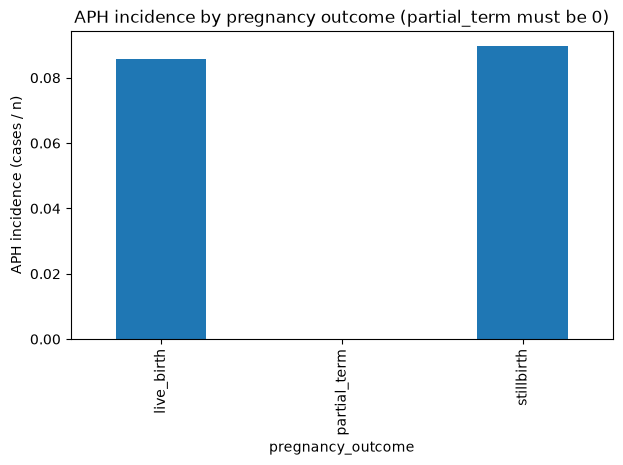

In [4]:
by_outcome = (
    aph_pop.assign(aph=aph_pop[COLUMNS.ANTEPARTUM_HEMORRHAGE].astype(bool))
    .groupby(COLUMNS.PREGNANCY_OUTCOME)['aph']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'aph_cases', 'count': 'n', 'mean': 'aph_incidence'})
)
display(by_outcome)

partial_term_cases = int(
    by_outcome.loc[PREGNANCY_OUTCOMES.PARTIAL_TERM_OUTCOME, 'aph_cases']
    if PREGNANCY_OUTCOMES.PARTIAL_TERM_OUTCOME in by_outcome.index else 0
)
assert partial_term_cases == 0, f'{partial_term_cases} partial_term simulants have APH == True'
print('PASSED: zero APH cases among partial_term pregnancies')

fig, ax = plt.subplots(figsize=(7, 4))
by_outcome['aph_incidence'].plot(kind='bar', ax=ax)
ax.set_ylabel('APH incidence (cases / n)')
ax.set_title('APH incidence by pregnancy outcome (partial_term must be 0)')
plt.show()

## APH vs intrapartum deaths are disjoint

2026-08-20 07:15:17.830 | INFO     | simulation_2-artifact_manager:80 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model39.0/ethiopia.hdf.


2026-08-20 07:15:17.831 | INFO     | simulation_2-artifact_manager:81 - Artifact base filter terms are ['draw == 60'].


2026-08-20 07:15:17.833 | INFO     | simulation_2-artifact_manager:82 - Artifact additional filter terms are None.


/ihme/homes/tylerdy/miniforge3/envs/vivarium_gates_mncnh_simulation/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))


/ihme/homes/tylerdy/miniforge3/envs/vivarium_gates_mncnh_simulation/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/ihme/homes/tylerdy/miniforge3/envs/vivarium_gates_mncnh_simulation/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/ihme/homes/tylerdy/miniforge3/envs/vivarium_gates_mncnh_simulation/lib/python3.11/site-pack

...

2026-08-20 07:16:53.138 | WARNING  | simulation_2-population_manager:747 - The 'maternal_sepsis_and_other_maternal_infections.incidence_risk.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'maternal_sepsis_and_other_maternal_infections.incidence_risk.paf'.


2026-08-20 07:16:53.277 | INFO     | simulation_2 - vivarium.framework.engine:280 - 2025-01-19 00:00:00


2026-08-20 07:16:54.188 | INFO     | simulation_2 - vivarium.framework.engine:280 - 2025-01-20 00:00:00


,deaths
cause_of_death,
residual_maternal_disorders,77
postpartum_hemorrhage,28
abortion_miscarriage_ectopic_pregnancy,19
antepartum_hemorrhage,19
maternal_sepsis_and_other_maternal_infections,9
maternal_obstructed_labor_and_uterine_rupture,7


/tmp/ipykernel_1881907/3008183097.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


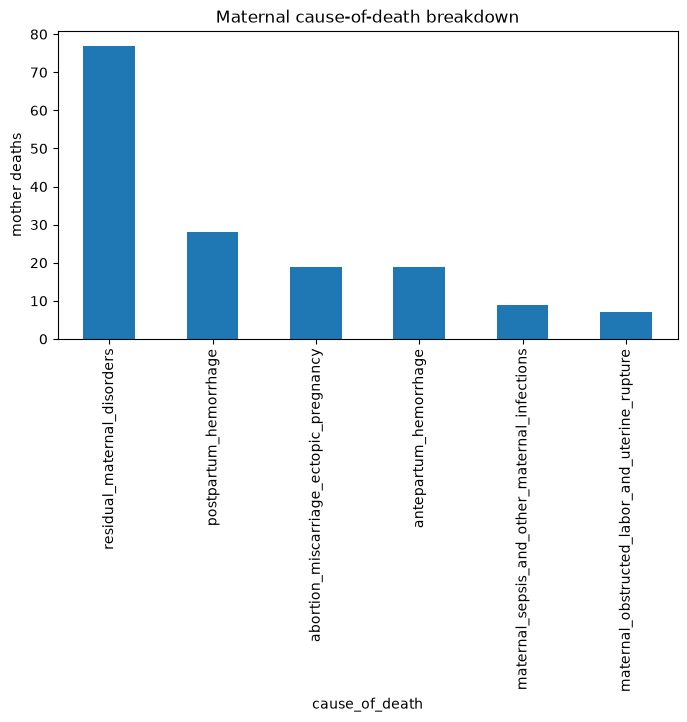

In [5]:
sim_mort = make_sim('baseline')
run_to_step(sim_mort, SIMULATION_EVENT_NAMES.MORTALITY)

mort_pop = sim_mort.get_population([
    COLUMNS.MOTHER_ALIVE,
    COLUMNS.MOTHER_CAUSE_OF_DEATH,
    COLUMNS.PREGNANCY_OUTCOME,
    COLUMNS.ABORTION_MISCARRIAGE_ECTOPIC_PREGNANCY,
    APH_SEVERITY_COL,
    PPH_SEVERITY_COL,
] + INTRAPARTUM_DISORDER_COLUMNS)

dead = mort_pop.loc[~mort_pop[COLUMNS.MOTHER_ALIVE]]
cod_breakdown = dead[COLUMNS.MOTHER_CAUSE_OF_DEATH].value_counts()
display(cod_breakdown.to_frame('deaths'))

fig, ax = plt.subplots(figsize=(8, 4))
cod_breakdown.plot(kind='bar', ax=ax)
ax.set_ylabel('mother deaths')
ax.set_title('Maternal cause-of-death breakdown')
plt.tight_layout()
plt.show()

In [6]:
# APH death excludes any intrapartum disorder / intrapartum death
aph_dead = mort_pop.index[mort_pop[COLUMNS.MOTHER_CAUSE_OF_DEATH] == COLUMNS.ANTEPARTUM_HEMORRHAGE]
intrapartum_dead = mort_pop.index[mort_pop[COLUMNS.MOTHER_CAUSE_OF_DEATH].isin(INTRAPARTUM_DISORDER_COLUMNS)]
print(f'APH deaths: {len(aph_dead)}; intrapartum-disorder deaths: {len(intrapartum_dead)}')

overlap = aph_dead.intersection(intrapartum_dead)
assert len(overlap) == 0, f'{len(overlap)} simulants recorded both APH and intrapartum death'

gating = {}
for disorder in INTRAPARTUM_DISORDER_COLUMNS:
    gating[disorder] = int(mort_pop.loc[aph_dead, disorder].astype(bool).sum())
gating_tbl = pd.Series(gating, name='intrapartum_flags_among_aph_dead').to_frame()
display(gating_tbl)
assert gating_tbl['intrapartum_flags_among_aph_dead'].sum() == 0, (
    'APH-dead simulants must not carry any intrapartum disorder incidence'
)
print('PASSED: APH deaths are disjoint from intrapartum disorders and intrapartum deaths')

APH deaths: 19; intrapartum-disorder deaths: 121


,intrapartum_flags_among_aph_dead
maternal_obstructed_labor_and_uterine_rupture,0
postpartum_hemorrhage,0
maternal_sepsis_and_other_maternal_infections,0
residual_maternal_disorders,0


PASSED: APH deaths are disjoint from intrapartum disorders and intrapartum deaths


In [7]:
# AME only for partial_term pregnancies
ame_non_partial = int((
    mort_pop[COLUMNS.ABORTION_MISCARRIAGE_ECTOPIC_PREGNANCY].astype(bool)
    & (mort_pop[COLUMNS.PREGNANCY_OUTCOME] != PREGNANCY_OUTCOMES.PARTIAL_TERM_OUTCOME)
).sum())
assert ame_non_partial == 0, f'{ame_non_partial} non-partial_term simulants have AME == True'
print('PASSED: AME assigned only to partial_term pregnancies')

PASSED: AME assigned only to partial_term pregnancies


TODO: In addition to the above (zero partial term APH cases) we could also double check that hemoglobin is not affected on APH step for partial term pregnancies. This is easy to check by tweaking model 38 checks once that is merged to main and merged into this branch. However will not do this bc we plan to remove APH component